In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import (
  adfuller,
  kpss,
)

In [2]:
# Define data locations
INTERIM_DIR = Path("../data/interim")

FILES = {
  "BTC": INTERIM_DIR / "btcusdt_1d_clean.parquet",
  "ETH": INTERIM_DIR / "ethusdt_1d_clean.parquet",
  "SOL": INTERIM_DIR / "solusdt_1d_clean.parquet",
  "BNB": INTERIM_DIR / "bnbusdt_1d_clean.parquet",

}

TRADING_DAYS = 365
ROLLING_VOL_WINDOW = 30
ROLLING_CORR_WINDOW = 90

In [3]:
# load datasets
data = {
  asset: pd.read_parquet(path)
  for asset, path in FILES.items()
}

## 1. Dataset Overview

In [4]:
# inspect data 
for asset, df in data.items():
  print(
    f"{asset}: "
    f"shape = {df.shape} | "
    f"start = {df['timestamp'].min()} | "
    f"end = {df['timestamp'].max()}"
  )

BTC: shape = (2105, 11) | start = 2021-01-01 00:00:00+00:00 | end = 2026-10-06 00:00:00+00:00
ETH: shape = (2105, 11) | start = 2021-01-01 00:00:00+00:00 | end = 2026-10-06 00:00:00+00:00
SOL: shape = (2105, 11) | start = 2021-01-01 00:00:00+00:00 | end = 2026-10-06 00:00:00+00:00
BNB: shape = (2105, 11) | start = 2021-01-01 00:00:00+00:00 | end = 2026-10-06 00:00:00+00:00


In [5]:
# inspect one dataset
data["BTC"].head()

,timestamp,symbol,open,high,low,close,volume,quote_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume
0,2021-01-01 00:00:00+00:00,BTCUSDT,28923.63,29600.00,28624.57,29331.69,54182.925011,1.582527e+09,1314910,27455.801725,8.022477e+08
1,2021-01-02 00:00:00+00:00,BTCUSDT,29331.70,33300.00,28946.53,32178.33,129993.873362,4.073842e+09,2245922,67446.305246,2.110335e+09
2,2021-01-03 00:00:00+00:00,BTCUSDT,32176.45,34778.11,31962.99,33000.05,120957.566750,4.057598e+09,2369698,59750.332871,2.004428e+09
3,2021-01-04 00:00:00+00:00,BTCUSDT,33000.05,33600.00,28130.00,31988.71,140899.885690,4.429010e+09,2642408,69088.469230,2.173435e+09
4,2021-01-05 00:00:00+00:00,BTCUSDT,31989.75,34360.00,29900.00,33949.53,116049.997038,3.743617e+09,2526851,59691.754755,1.927195e+09


In [6]:
data["BTC"].info()

<class 'pandas.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   timestamp               2105 non-null   datetime64[ms, UTC]
 1   symbol                  2105 non-null   str                
 2   open                    2105 non-null   float64            
 3   high                    2105 non-null   float64            
 4   low                     2105 non-null   float64            
 5   close                   2105 non-null   float64            
 6   volume                  2105 non-null   float64            
 7   quote_volume            2105 non-null   float64            
 8   number_of_trades        2105 non-null   int32              
 9   taker_buy_base_volume   2105 non-null   float64            
 10  taker_buy_quote_volume  2105 non-null   float64            
dtypes: datetime64[ms, UTC](1), float64(8), int32(1), str(1

In [7]:
# Check missing values
missing_summary = pd.DataFrame(
  {
    asset: df.isna().sum()
    for asset, df in data.items()
  }
)

missing_summary

,BTC,ETH,SOL,BNB
timestamp,0,0,0,0
symbol,0,0,0,0
open,0,0,0,0
high,0,0,0,0
low,0,0,0,0
close,0,0,0,0
volume,0,0,0,0
quote_volume,0,0,0,0
number_of_trades,0,0,0,0
taker_buy_base_volume,0,0,0,0


In [8]:
# check duplicates
for asset, df in data.items():
    duplicates = df["timestamp"].duplicated().sum()

    print(
        f"{asset}: {duplicates} duplicate timestamps"
    )

BTC: 0 duplicate timestamps
ETH: 0 duplicate timestamps
SOL: 0 duplicate timestamps
BNB: 0 duplicate timestamps


In [9]:
# confirm chronological
for asset, df in data.items():
  is_sorted = df["timestamp"].is_monotonic_increasing

  print(
    f"{asset}: chronologically sorted? {is_sorted}"
  )

BTC: chronologically sorted? True
ETH: chronologically sorted? True
SOL: chronologically sorted? True
BNB: chronologically sorted? True


In [10]:
# descriptive statistics
summary_columns = [
  "open",
  "high",
  "low",
  "close",
  "volume",
  "quote_volume",
  "number_of_trades"
]

for asset, df in data.items():
  print(f"\n{asset}")

  display(
    df[summary_columns].describe()
  )


BTC


,open,high,low,close,volume,quote_volume,number_of_trades
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2.105000e+03,2.105000e+03
mean,56901.576342,58028.869444,55699.194466,56928.529663,67131.568267,2.499208e+09,2.947348e+06
std,28380.042346,28741.541815,27993.283381,28380.335701,89380.697947,1.954747e+09,2.343822e+06
min,15781.290000,16315.000000,15476.000000,15781.290000,3104.117220,2.508740e+08,3.108520e+05
25%,30692.440000,31765.640000,30049.980000,30766.510000,19988.492590,1.247834e+09,1.280351e+06
50%,55011.970000,57076.240000,53400.000000,55025.590000,35351.870910,1.925459e+09,2.101404e+06
75%,76346.580000,77505.670000,75323.650000,76417.010000,68437.801870,3.119019e+09,3.933123e+06
max,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,1.746531e+10,1.536401e+07



ETH


,open,high,low,close,volume,quote_volume,number_of_trades
count,2105.000000,2105.000000,2105.000000,2105.000000,2.105000e+03,2.105000e+03,2.105000e+03
mean,2491.370114,2559.679582,2416.630651,2492.306504,5.558898e+05,1.324299e+09,1.984646e+06
std,870.107821,892.382083,843.661965,869.285909,4.330031e+05,9.889953e+08,1.912025e+06
min,728.910000,749.000000,714.290000,728.910000,4.819709e+04,9.074624e+07,1.541100e+05
25%,1806.800000,1841.340000,1762.770000,1807.450000,2.871313e+05,6.495388e+08,7.488040e+05
50%,2352.970000,2428.230000,2285.420000,2354.010000,4.431953e+05,1.087476e+09,1.200519e+06
75%,3124.160000,3217.240000,3044.030000,3124.160000,6.784002e+05,1.710124e+09,2.597350e+06
max,4832.070000,4956.780000,4713.890000,4832.070000,4.309836e+06,1.164152e+10,1.366759e+07



SOL


,open,high,low,close,volume,quote_volume,number_of_trades
count,2105.000000,2105.000000,2105.000000,2105.000000,2.105000e+03,2.105000e+03,2.105000e+03
mean,97.556791,101.236543,93.816423,97.612940,4.359570e+06,4.045739e+08,9.834978e+05
std,67.060481,69.344093,64.612243,67.029656,3.326949e+06,4.454548e+08,1.151158e+06
min,1.508800,1.860000,1.499000,1.799900,6.021138e+05,7.454787e+06,2.550000e+04
25%,31.610000,33.000000,30.402000,31.630000,2.358777e+06,1.166030e+08,2.377220e+05
50%,90.440000,93.930000,87.000000,90.720000,3.487479e+06,2.797436e+08,5.917580e+05
75%,148.600000,154.000000,144.110000,148.600000,5.123656e+06,5.523338e+08,1.329012e+06
max,261.970000,295.830000,252.690000,261.970000,3.496502e+07,6.733959e+09,1.672892e+07



BNB


,open,high,low,close,volume,quote_volume,number_of_trades
count,2105.000000,2105.000000,2105.000000,2105.000000,2.105000e+03,2.105000e+03,2.105000e+03
mean,484.628795,496.186498,472.154714,484.969450,8.608443e+05,3.239772e+08,7.109634e+05
std,220.906460,225.270244,216.209842,220.790783,1.465337e+06,4.675810e+08,6.746635e+05
min,37.359600,38.879800,35.037400,37.776200,5.127256e+04,2.035635e+07,5.457000e+04
25%,299.400000,306.800000,289.000000,299.500000,2.011006e+05,9.458572e+07,2.782210e+05
50%,489.500000,505.200000,471.000000,490.000000,4.028130e+05,1.636634e+08,5.058540e+05
75%,622.580000,636.590000,609.580000,622.630000,8.498258e+05,3.486527e+08,8.958850e+05
max,1307.400000,1375.110000,1264.320000,1307.400000,2.018886e+07,5.528653e+09,6.244627e+06


The four datasets contain aligned daily observations over the same research period. No missing observations or duplicate timestamps are present, and the data are chronologically ordered. This provides a consistent foundation for cross-asset analysis and later time-series modelling.

## 2. Price Behaviour

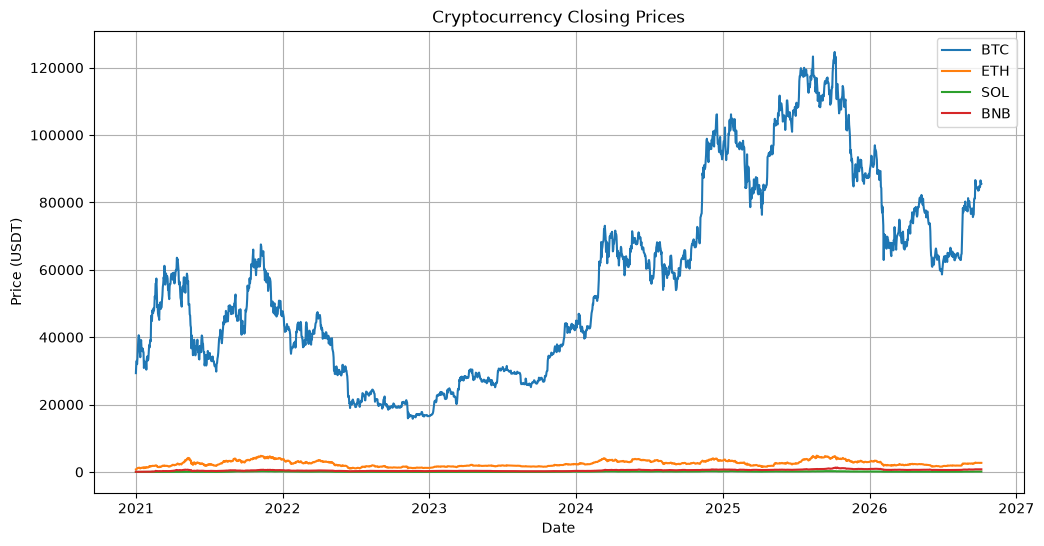

In [11]:
# create closing price plot
fig, ax = plt.subplots(figsize=(12, 6))

for asset, df in data.items():
    ax.plot(
        df["timestamp"],
        df["close"],
        label=asset,
    )

ax.set_title("Cryptocurrency Closing Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USDT)")
ax.legend()
ax.grid(True)

plt.show()

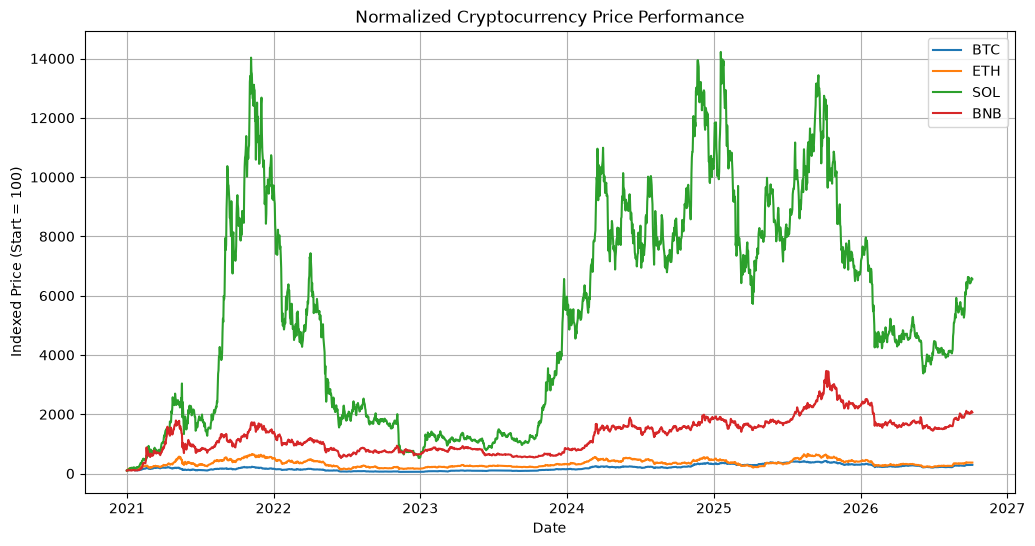

In [12]:
# create a normalized closing price plot
fig, ax = plt.subplots(figsize=(12, 6))

for asset, df in data.items():
    normalized_price = (
        df["close"] / df["close"].iloc[0]
    ) * 100

    ax.plot(
        df["timestamp"],
        normalized_price,
        label=asset,
    )

ax.set_title("Normalized Cryptocurrency Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Start = 100)")
ax.legend()
ax.grid(True)

plt.show()
  

The raw-price series are not directly comparable because the assets trade at very different nominal price levels. Normalizing each series to a common starting value reveals substantial differences in relative performance.

SOL exhibits the strongest relative growth but also the most pronounced boom-bust behaviour. BNB also experiences substantial appreciation, while BTC and ETH show more moderate relative growth.

The assets broadly share major market cycles, suggesting meaningful cross-asset dependence. These characteristics motivate analysing returns and volatility rather than modelling raw price levels directly.

## 3. Log Returns

In [13]:
# create log returns
for _asset, df in data.items():
    df["log_return"] = np.log(
        df["close"] / df["close"].shift(1)
    )

In [14]:
# inspect the first few rows
data["BTC"][
  [
    "timestamp", 
    "close", 
    "log_return"
  ]
].head()

,timestamp,close,log_return
0,2021-01-01 00:00:00+00:00,29331.69,NaN
1,2021-01-02 00:00:00+00:00,32178.33,0.092625
2,2021-01-03 00:00:00+00:00,33000.05,0.025216
3,2021-01-04 00:00:00+00:00,31988.71,-0.031126
4,2021-01-05 00:00:00+00:00,33949.53,0.059492


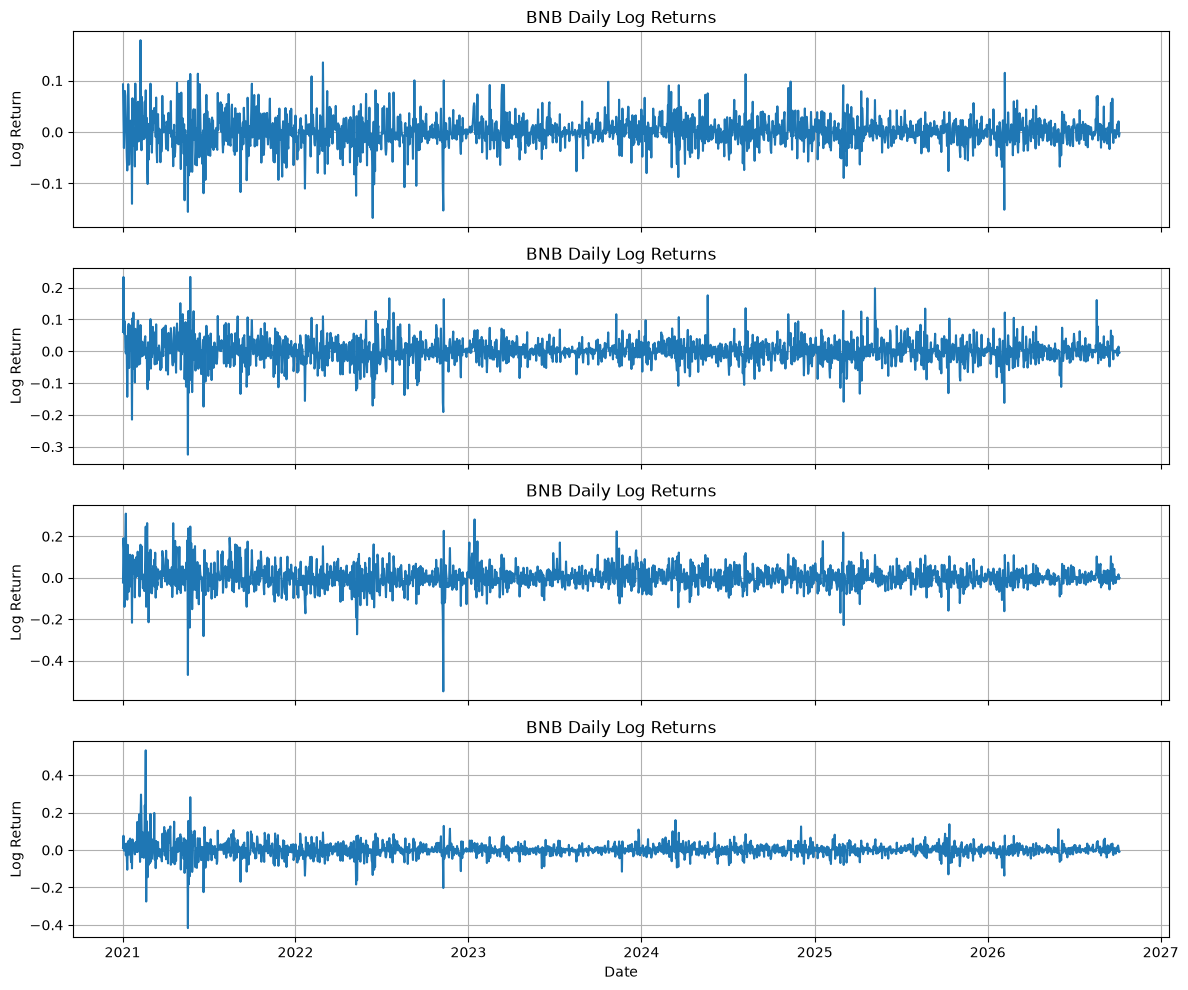

In [ ]:
# create plot for log returns
fig, axes = plt.subplots(
  4,
  1,
  figsize=(12, 10),
  sharex=True
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    ax.plot(
        df["timestamp"],
        df["log_return"],
    )

    ax.set_title(f"{asset} Daily Log Returns")
    ax.set_ylabel("Log Return")
    ax.grid(True)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [16]:
# calculate return summary statistics

return_summary = pd.DataFrame(
  {
    asset: df["log_return"].describe()
    for asset, df in data.items()
  }
).T

# add skewness and kurtosis
return_summary["skewness"] = [
  df["log_return"].skew()
  for df in data.values()
]

return_summary["kurtosis"] = [
  df["log_return"].kurt()
  for df in data.values()
]

return_summary

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
BTC,2104.0,0.000509,0.029841,-0.166998,-0.013213,-0.000086,0.014020,0.178449,-0.109106,4.118726
ETH,2104.0,0.000622,0.040317,-0.324861,-0.018089,0.000854,0.019846,0.233750,-0.179418,5.597724
SOL,2104.0,0.001988,0.056785,-0.549008,-0.027702,0.000178,0.029297,0.309672,-0.362459,9.235248
BNB,2104.0,0.001439,0.040773,-0.416712,-0.014198,0.001158,0.015722,0.532404,0.833431,25.197568


Daily log returns are centred close to zero but exhibit substantial time-varying dispersion and frequent extreme observations.

SOL has the highest return standard deviation, indicating greater daily variability, while BTC is comparatively less volatile.

BTC, ETH, and SOL exhibit mild negative skewness, suggesting somewhat heavier downside tails. BNB displays positive skewness because of unusually large positive returns.

All four assets exhibit strongly positive excess kurtosis, indicating fat-tailed distributions with substantially more extreme observations than expected under normality.

The return plots also suggest volatility clustering: periods of large price movements tend to occur near other periods of large movements.

## 4. Volatility Analysis

In [17]:
# 30-day rolling volatility
for _asset, df in data.items():
    df["rolling_vol_30d"] = (
        df["log_return"]
        .rolling(ROLLING_VOL_WINDOW)
        .std()
    )

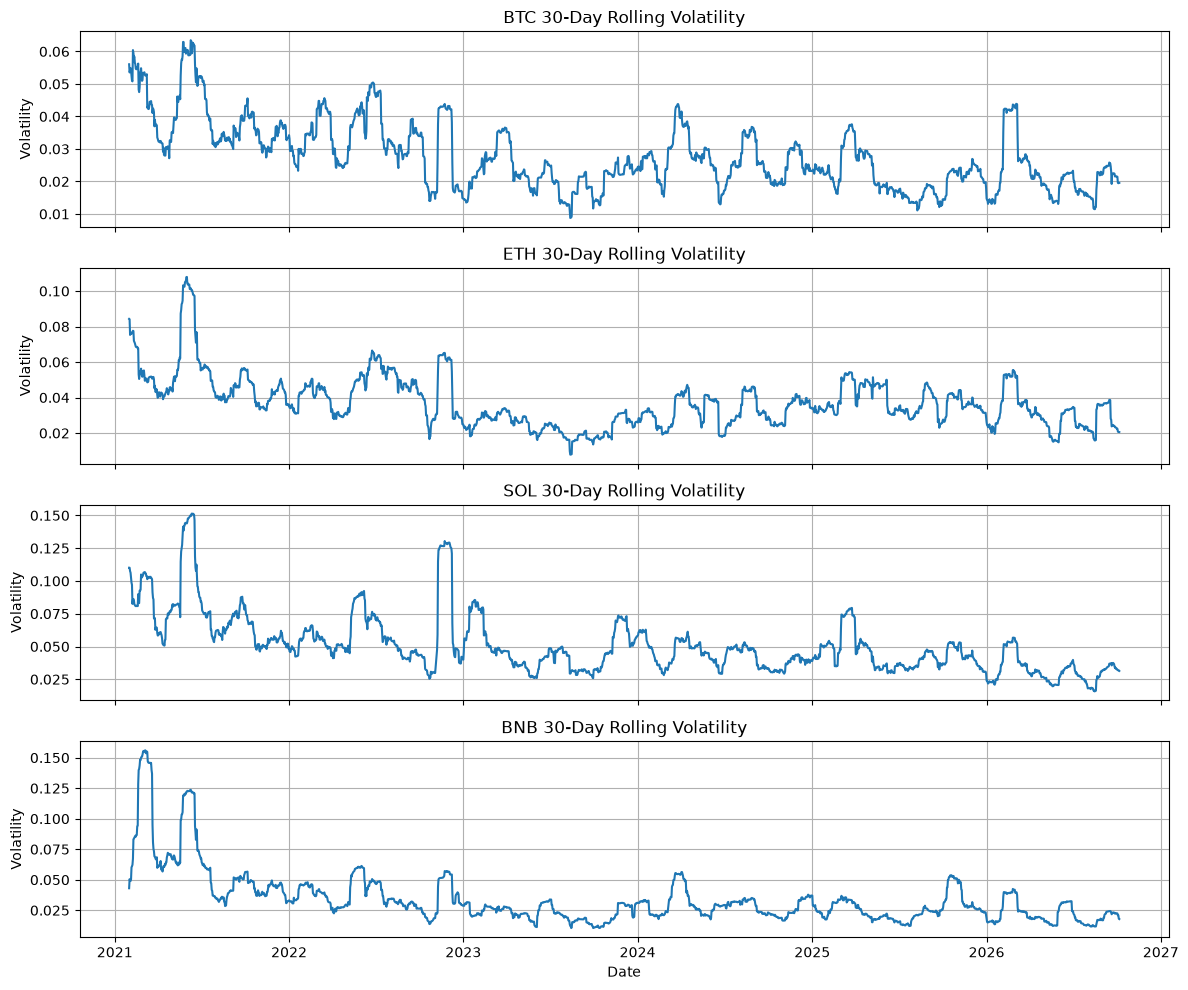

In [ ]:
# plot rolling volatility
fig, axes = plt.subplots(
  4,
  1,
  figsize=(12, 10),
  sharex=True
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    ax.plot(
        df["timestamp"],
        df["rolling_vol_30d"],
    )

    ax.set_title(f"{asset} 30-Day Rolling Volatility")
    ax.set_ylabel("Volatility")
    ax.grid(True)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [19]:
# annualized volatility

for _asset, df in data.items():
    df["rolling_vol_30d_annualized"] = (
        df["rolling_vol_30d"] 
        * np.sqrt(TRADING_DAYS)
    )

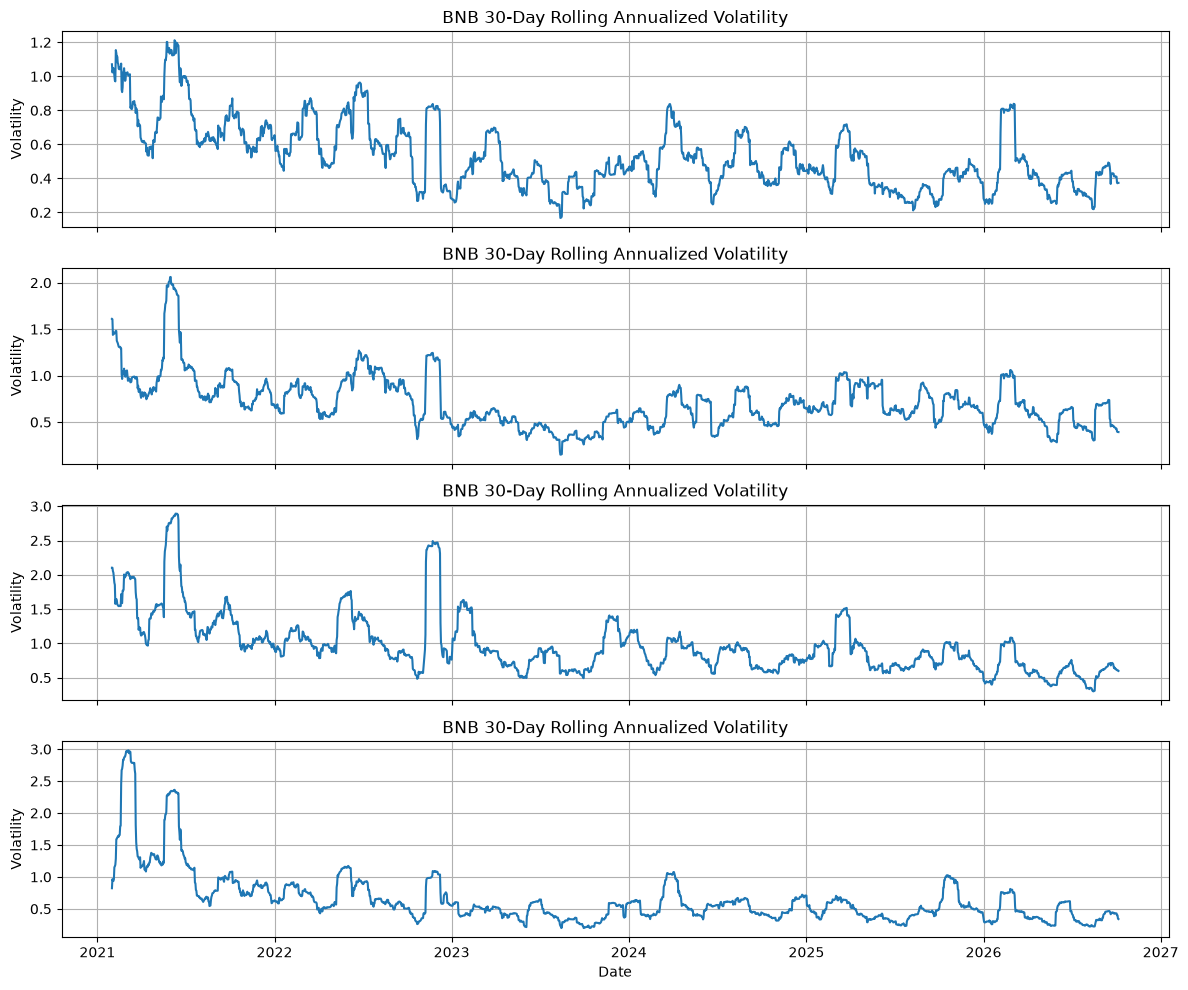

In [ ]:
# plot annualized volatility
fig, axes = plt.subplots(
  4,
  1,
  figsize=(12, 10),
  sharex=True
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    ax.plot(
        df["timestamp"],
        df["rolling_vol_30d_annualized"],
    )

    ax.set_title(f"{asset} 30-Day Rolling Annualized Volatility")
    ax.set_ylabel("Volatility")
    ax.grid(True)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### Garman–Klass Volatility

The Garman–Klass estimator uses the daily open, high, low, and close prices rather than relying only on close-to-close returns.

This allows the estimator to incorporate information about the intraday trading range.

In [21]:
# calculate Garman-Klass volatility

for _asset, df in data.items():
    log_hl = np.log(
        df["high"] / df["low"]
    )
    
    log_co = np.log(
        df["close"] / df["open"]
    )

    df["gk_variance"] = (
        0.5 * log_hl.pow(2) 
        - (2 * np.log(2) - 1) * log_co.pow(2)
    )


In [22]:
for _asset, df in data.items():
    negative_count = (
        df["gk_variance"] < 0
    ).sum()

    minimum_variance = df["gk_variance"].min()

    print(
        f"{asset}: "
        f"{negative_count} negative GK variances | "
        f"minimum={minimum_variance}"
    )

BNB: 0 negative GK variances | minimum=5.74037934972401e-06
BNB: 0 negative GK variances | minimum=9.052375470551507e-06
BNB: 0 negative GK variances | minimum=4.127653289617382e-05
BNB: 0 negative GK variances | minimum=1.529752571396782e-05


In [23]:
# calculate Garman-Klass volatility from variance
for _asset, df in data.items():
    df["gk_volatility"] = np.sqrt(
        df["gk_variance"].clip(lower=0)
    )

In [24]:
# annualized Garman-Klass volatility
for _asset, df in data.items():
    df["gk_volatility_annualized"] = (
        df["gk_volatility"]
        * np.sqrt(TRADING_DAYS)
    )

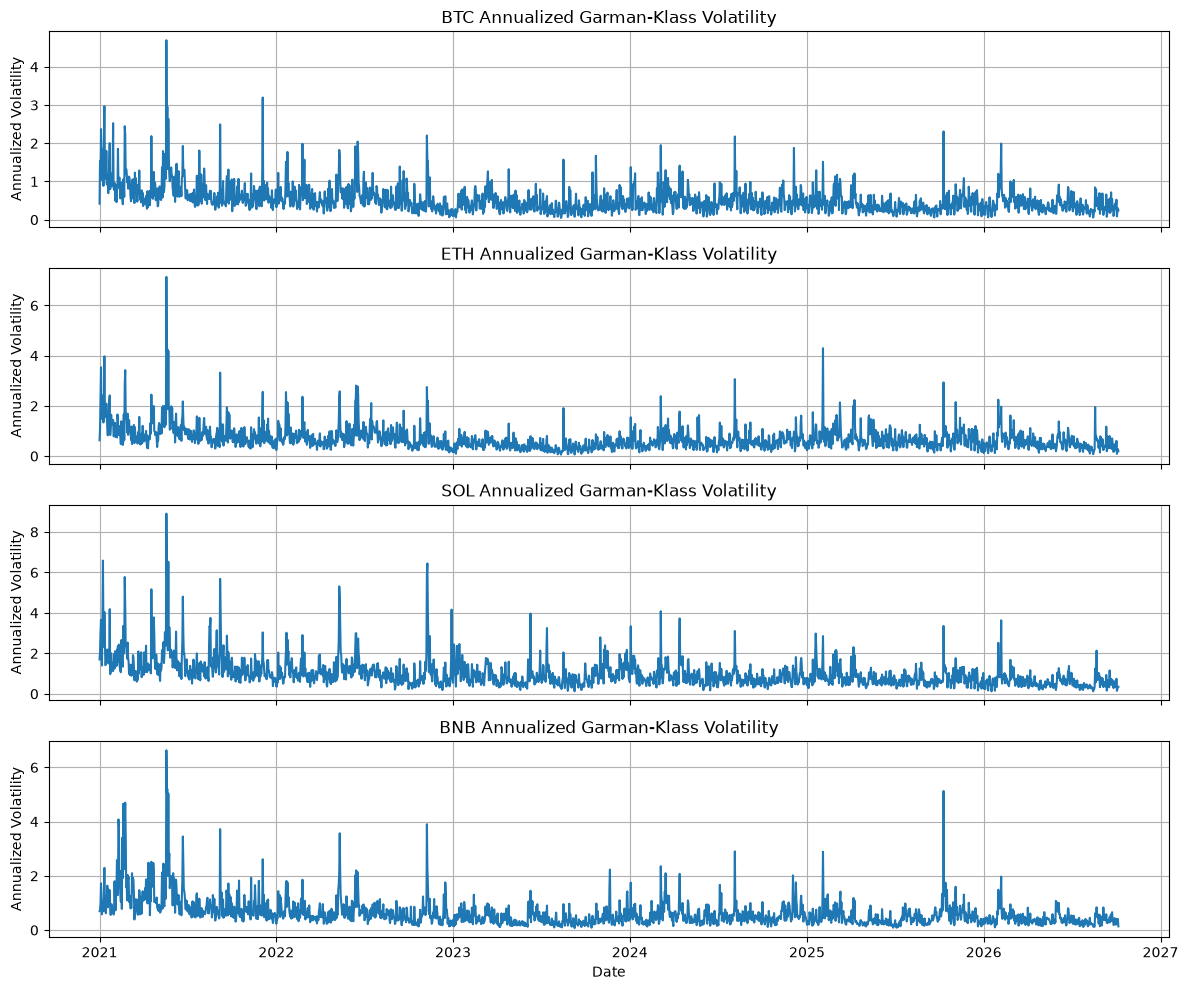

In [ ]:
# plot Garman-Klass volatility
fig, axes = plt.subplots(
  4,
  1,
  figsize=(12, 10),
  sharex=True,
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    ax.plot(
        df["timestamp"],
        df["gk_volatility_annualized"],
    )

    ax.set_title(
        f"{asset} Annualized Garman-Klass Volatility"
    )
    ax.set_ylabel("Annualized Volatility")
    ax.grid(True)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()


In [26]:
# summary statistics of annualized Garman-Klass volatility

volatility_summary = pd.DataFrame(
  {
    asset: (
      df["gk_volatility_annualized"]
      .describe()
    )
    for asset, df in data.items()
  }
).T

volatility_summary[
  [
    "mean",
    "std",
    "min",
    "50%",
    "max",
  ]
]


,mean,std,min,50%,max
BTC,0.516406,0.358179,0.045774,0.438650,4.697344
ETH,0.683057,0.471340,0.057481,0.573830,7.135795
SOL,0.989733,0.704138,0.122743,0.821337,8.906912
BNB,0.623553,0.534471,0.074723,0.486978,6.627930


Volatility is strongly time-varying across all four cryptocurrencies.

The rolling volatility series display clear volatility clustering and persistent high- and low-risk periods. SOL and BNB generally experience the largest volatility spikes, while BTC is comparatively less volatile.

The Garman–Klass estimator responds strongly to individual daily shocks because it incorporates the high-low trading range and open-close movement. These patterns support the use of models that explicitly allow volatility to change and persist through time.

## 5. Distribution Diagnostics

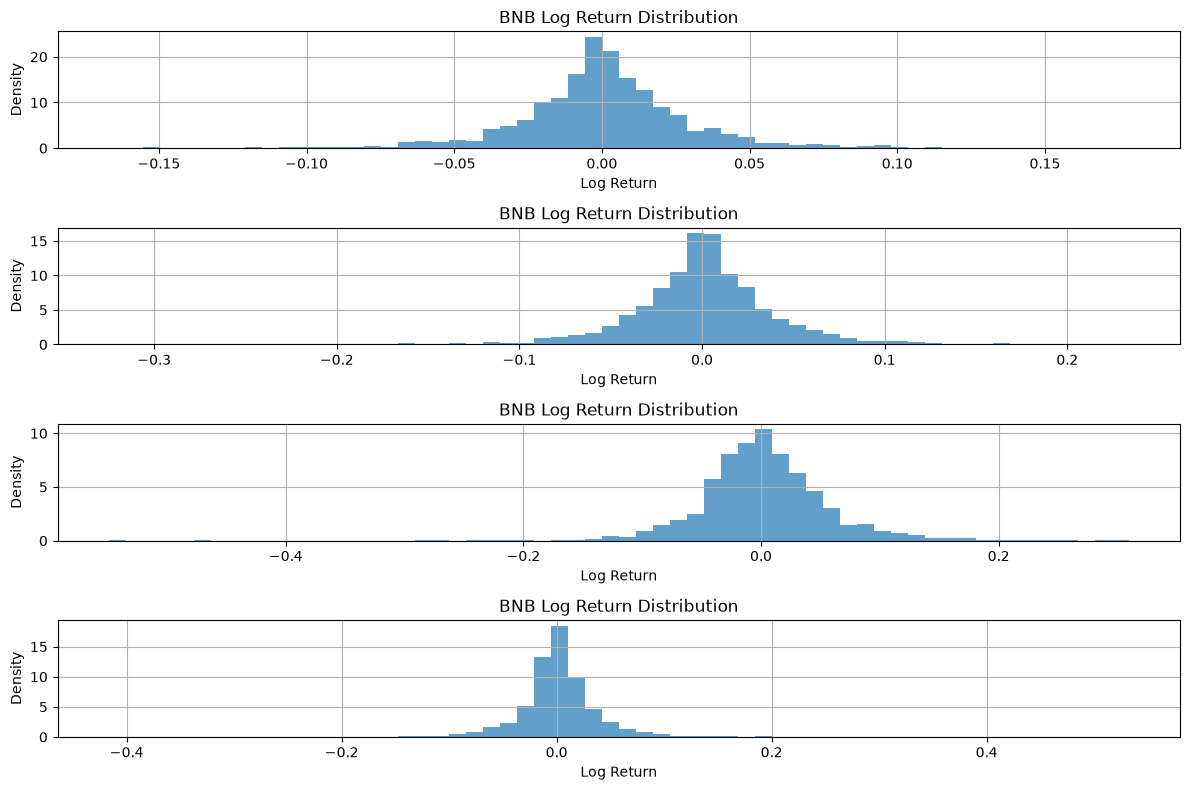

In [ ]:
# plot return histogram
fig, axes = plt.subplots(
  4,
  1,
  figsize=(12, 8),
)

axes = axes.flatten()

for ax, (asset, df) in zip(axes, data.items(), strict=True):
  returns = df["log_return"].dropna()

  ax.hist(
    returns,
    bins=60,
    density=True,
    alpha=0.7,
  )

  ax.set_title(f"{asset} Log Return Distribution")
  ax.set_xlabel("Log Return")
  ax.set_ylabel("Density")
  ax.grid(True)

plt.tight_layout()
plt.show()


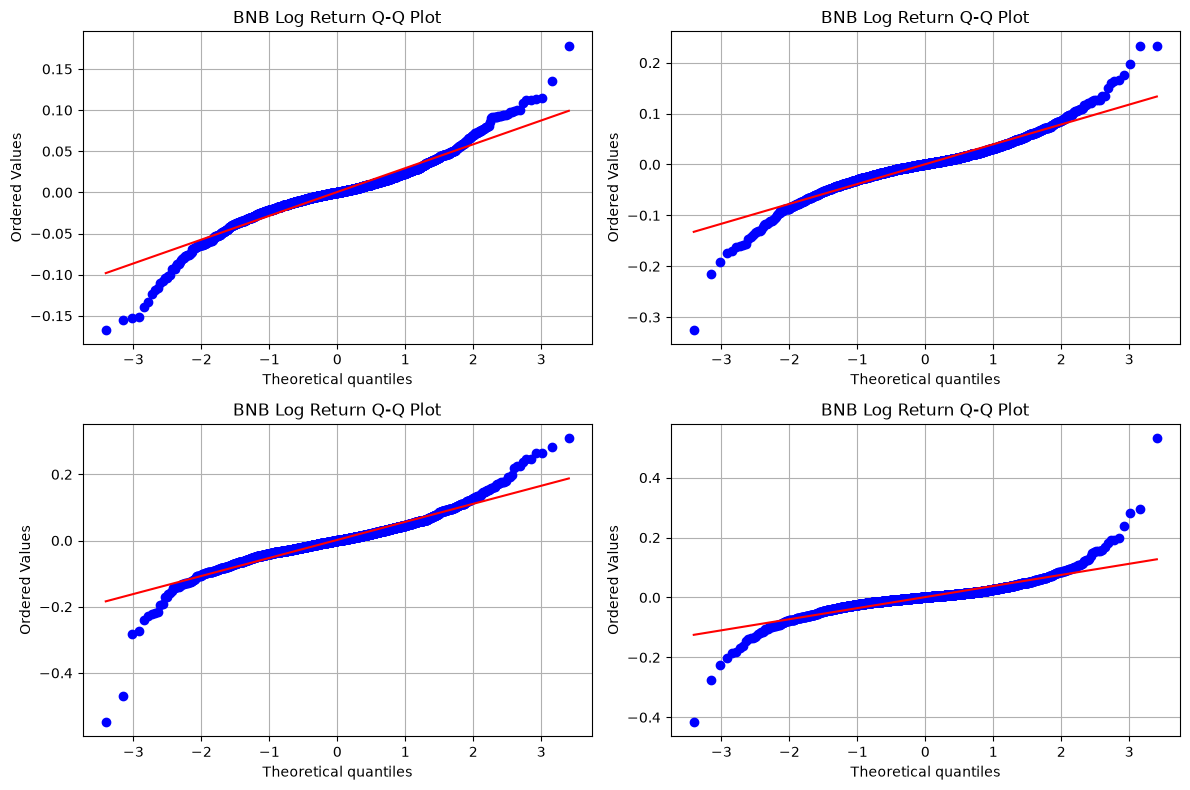

In [ ]:
# Q-Q Plot
fig, axes = plt.subplots(
  2,
  2,
  figsize=(12, 8),
)

axes = axes.flatten()

for ax, (_asset, df) in zip(axes, data.items(), strict=True):
  returns = df["log_return"].dropna()

  stats.probplot(
    returns,
    dist="norm",
    plot=ax,
  )

  ax.set_title(f"{asset} Log Return Q-Q Plot")
  ax.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Jarque-Bera Test for Normality
normality_results = []

for asset, df in data.items():
  returns = df["log_return"].dropna()

  statistic, p_value = stats.jarque_bera(returns)

  normality_results.append(
    {
      "asset": asset,
      "jb_statistic": statistic,
      "p_value": p_value,
    }
  )

normality_results = pd.DataFrame(normality_results)

normality_results

,asset,jb_statistic,p_value
0,BTC,1482.229601,0.0
1,ETH,2742.442047,0.0
2,SOL,7483.001692,0.0
3,BNB,55627.701989,0.0


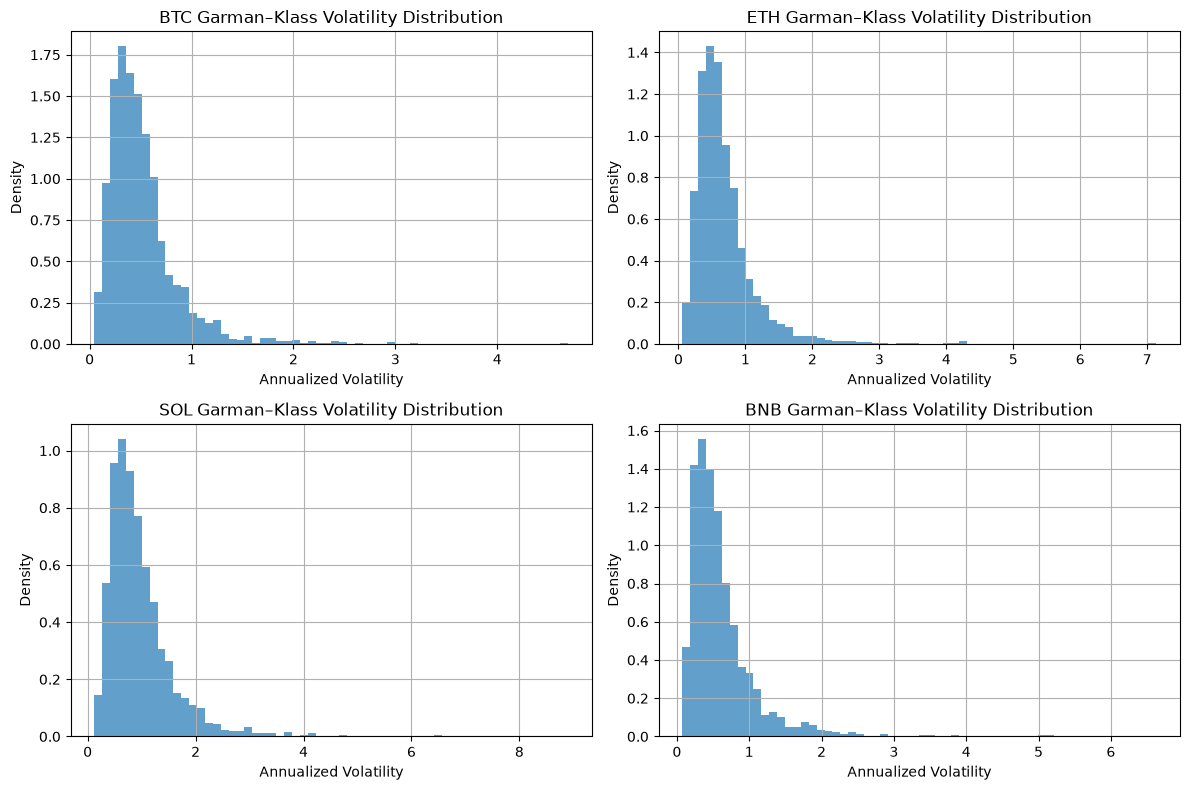

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes = axes.flatten()

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    volatility = df["gk_volatility_annualized"].dropna()

    ax.hist(
        volatility,
        bins=60,
        density=True,
        alpha=0.7,
    )

    ax.set_title(
        f"{asset} Garman–Klass Volatility Distribution"
    )
    ax.set_xlabel("Annualized Volatility")
    ax.set_ylabel("Density")
    ax.grid(True)

plt.tight_layout()
plt.show()

Daily cryptocurrency returns show substantial departures from normality.

Return distributions are sharply concentrated around zero but exhibit long tails. Q-Q plots show strong deviations from a normal distribution at extreme quantiles.

Jarque–Bera tests reject normality for all four assets.

Garman–Klass volatility distributions are strongly right-skewed: most observations occur at moderate volatility levels, while a smaller number of observations represent extreme volatility events.

These results indicate that crypto returns are fat-tailed and that volatility is strongly non-Gaussian.

## 6. Correlation Analysis

In [31]:
returns_df = pd.DataFrame(
    {
        asset: (
          df.set_index("timestamp")
          ["log_return"]
        )
        for asset, df in data.items()
    }
).dropna()

returns_df.head()

,BTC,ETH,SOL,BNB
timestamp,,,,
2021-01-02 00:00:00+00:00,0.092625,0.060745,-0.023175,0.012022
2021-01-03 00:00:00+00:00,0.025216,0.233501,0.190630,0.076131
2021-01-04 00:00:00+00:00,-0.031126,0.062554,0.134283,-0.003015
2021-01-05 00:00:00+00:00,0.059492,0.054315,-0.140871,0.016602
2021-01-06 00:00:00+00:00,0.079790,0.094404,-0.108364,0.009988


In [32]:
return_correlation = returns_df.corr()

return_correlation

,BTC,ETH,SOL,BNB
BTC,1.000000,0.822479,0.629613,0.668505
ETH,0.822479,1.000000,0.675080,0.680204
SOL,0.629613,0.675080,1.000000,0.597244
BNB,0.668505,0.680204,0.597244,1.000000


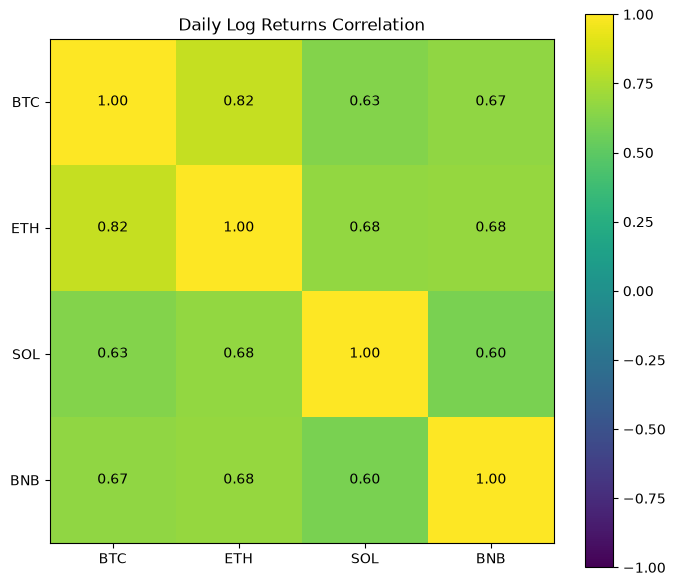

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    return_correlation,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(return_correlation.columns)))
ax.set_xticklabels(return_correlation.columns)

ax.set_yticks(range(len(return_correlation.index)))
ax.set_yticklabels(return_correlation.index)

for i in range(len(return_correlation.index)):
    for j in range(len(return_correlation.columns)):
        ax.text(
            j,
            i,
            f"{return_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Daily Log Returns Correlation")

fig.colorbar(image)

plt.tight_layout()
plt.show()

In [34]:
volatility_df = pd.DataFrame(
  {
    asset: (
      df
      .set_index("timestamp")
      ["gk_volatility_annualized"]
    )
    for asset, df in data.items()
  }
)

volatility_correlation = volatility_df.corr()

volatility_correlation

,BTC,ETH,SOL,BNB
BTC,1.000000,0.873353,0.761438,0.742253
ETH,0.873353,1.000000,0.771982,0.760147
SOL,0.761438,0.771982,1.000000,0.758730
BNB,0.742253,0.760147,0.758730,1.000000


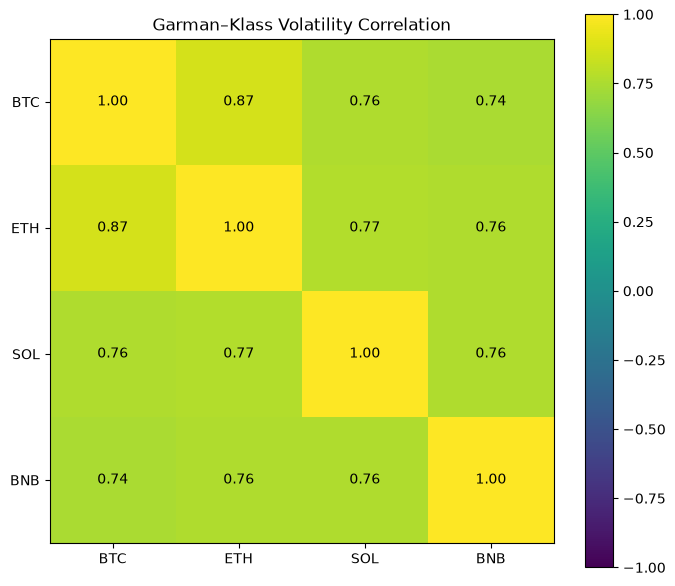

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    volatility_correlation,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(volatility_correlation.columns)))
ax.set_xticklabels(volatility_correlation.columns)

ax.set_yticks(range(len(volatility_correlation.index)))
ax.set_yticklabels(volatility_correlation.index)

for i in range(len(volatility_correlation.index)):
    for j in range(len(volatility_correlation.columns)):
        ax.text(
            j,
            i,
            f"{volatility_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Garman–Klass Volatility Correlation")

fig.colorbar(image)

plt.tight_layout()
plt.show()

Return correlations are positive across all four cryptocurrencies, with BTC and ETH displaying the strongest relationship.

Volatility correlations are even stronger across many pairs, suggesting that periods of elevated market risk tend to affect multiple cryptocurrencies simultaneously.

This indicates that diversification benefits may weaken during periods of market stress and provides motivation for later cross-asset volatility and spillover analysis.

## Rolling Correlations

In [36]:
# calculate rolling correlations between BTC and other assets
btc_eth_rolling_corr = (
    returns_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(returns_df["ETH"])
)

btc_sol_rolling_corr = (
    returns_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(returns_df["SOL"])
)

btc_bnb_rolling_corr = (
    returns_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(returns_df["BNB"])
)

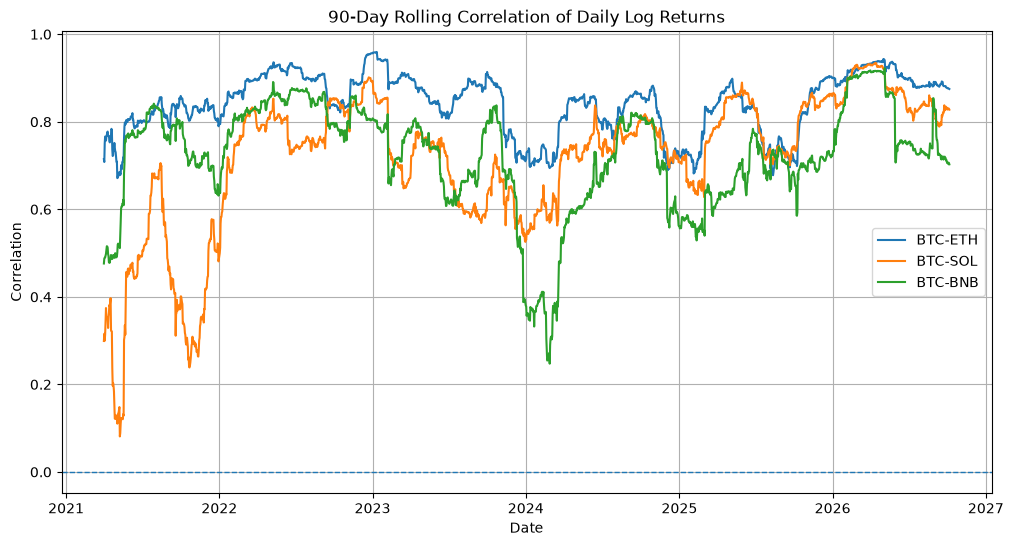

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    btc_eth_rolling_corr.index,
    btc_eth_rolling_corr,
    label="BTC-ETH",
)

ax.plot(
    btc_sol_rolling_corr.index,
    btc_sol_rolling_corr,
    label="BTC-SOL",
)

ax.plot(
    btc_bnb_rolling_corr.index,
    btc_bnb_rolling_corr,
    label="BTC-BNB",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "90-Day Rolling Correlation of Daily Log Returns"
)
ax.set_xlabel("Date")
ax.set_ylabel("Correlation")
ax.legend()
ax.grid(True)

plt.show()

In [ ]:
# calculate rolling correlations between BTC and other assets 
# based on annualized Garman-Klass volatility
btc_eth_vol_corr = (
    volatility_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(volatility_df["ETH"])
)

btc_sol_vol_corr = (
    volatility_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(volatility_df["SOL"])
)

btc_bnb_vol_corr = (
    volatility_df["BTC"]
    .rolling(ROLLING_CORR_WINDOW)
    .corr(volatility_df["BNB"])
)

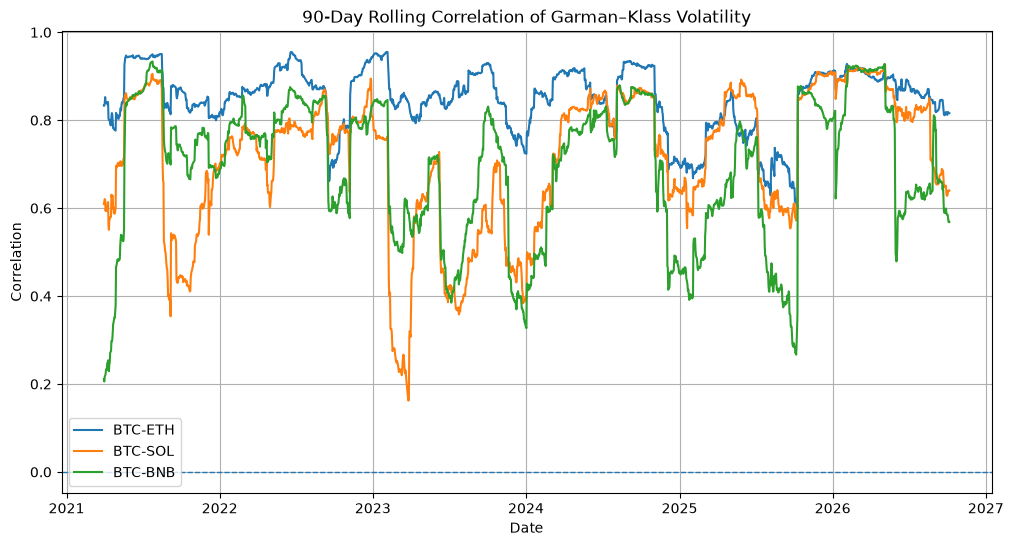

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    btc_eth_vol_corr.index,
    btc_eth_vol_corr,
    label="BTC-ETH",
)

ax.plot(
    btc_sol_vol_corr.index,
    btc_sol_vol_corr,
    label="BTC-SOL",
)

ax.plot(
    btc_bnb_vol_corr.index,
    btc_bnb_vol_corr,
    label="BTC-BNB",
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "90-Day Rolling Correlation of Garman–Klass Volatility"
)
ax.set_xlabel("Date")
ax.set_ylabel("Correlation")
ax.legend()
ax.grid(True)

plt.show()

Rolling correlations show that cross-asset relationships are not constant through time.

BTC and ETH maintain the strongest and most persistent relationship, while BTC-SOL and BTC-BNB correlations vary more substantially.

Periods of high correlation indicate reduced diversification benefits, while lower-correlation periods provide greater diversification potential.

This time variation motivates dynamic portfolio allocation rather than relying on a fixed covariance structure.

## 7. Volatility clustering and Autocorrelation

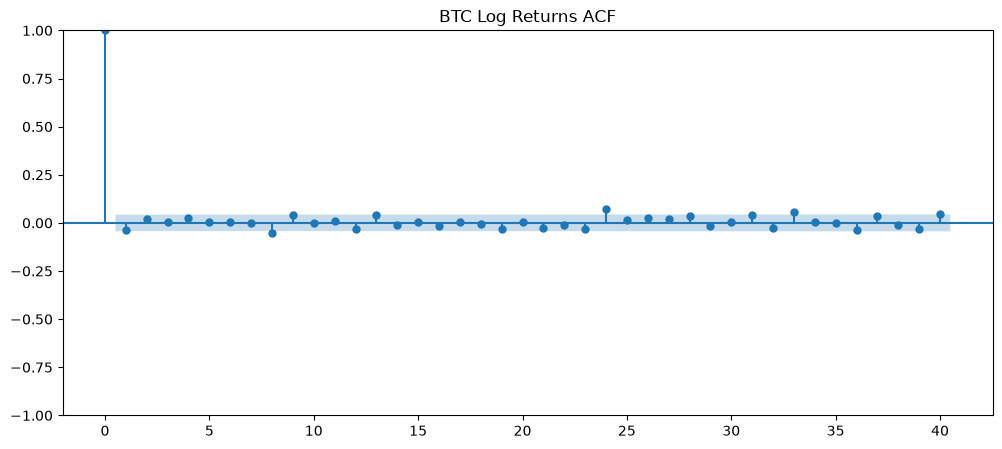

In [40]:
# ACF Auto-Correlation Function Analysis
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    data["BTC"]["log_return"].dropna(),
    lags=40,
    ax=ax,
)

ax.set_title("BTC Log Returns ACF")

plt.show()

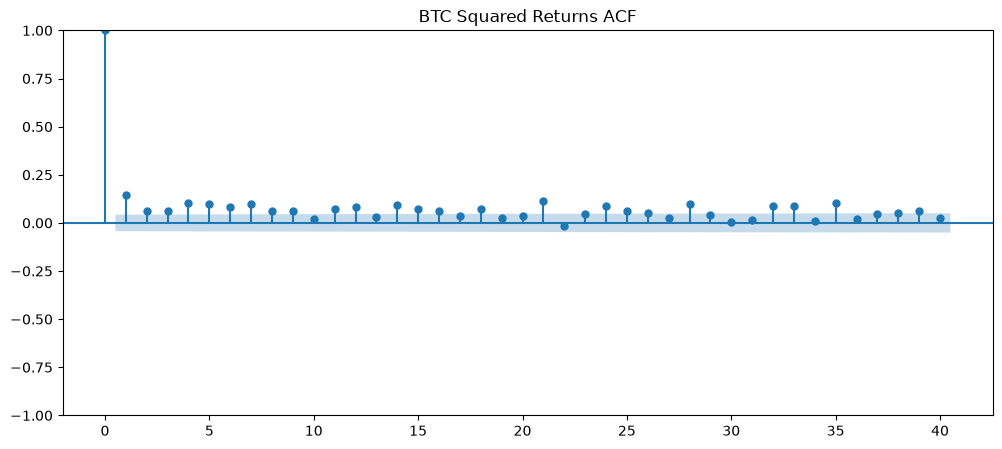

In [41]:
btc_squared_returns = (
    data["BTC"]["log_return"]
    .dropna()
    .pow(2)
)

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    btc_squared_returns,
    lags=40,
    ax=ax,
)

ax.set_title("BTC Squared Returns ACF")

plt.show()

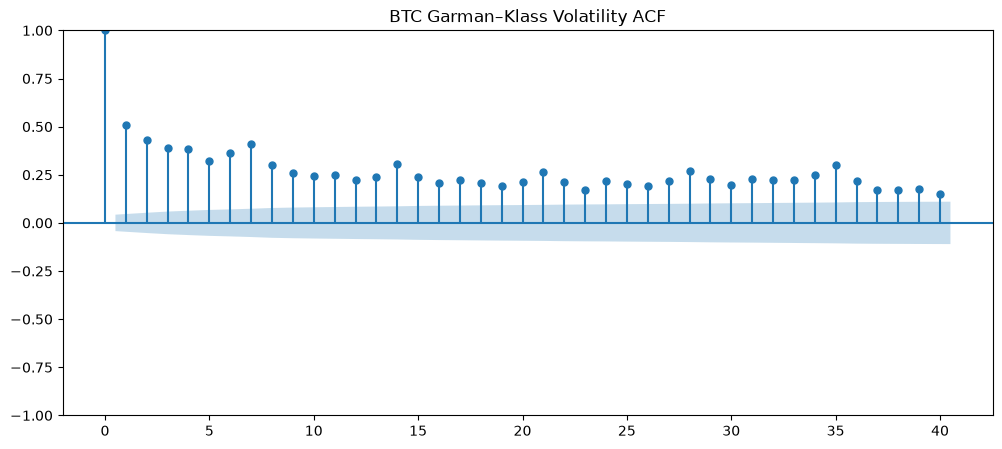

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    data["BTC"]["gk_volatility_annualized"].dropna(),
    lags=40,
    ax=ax,
)

ax.set_title("BTC Garman–Klass Volatility ACF")

plt.show()

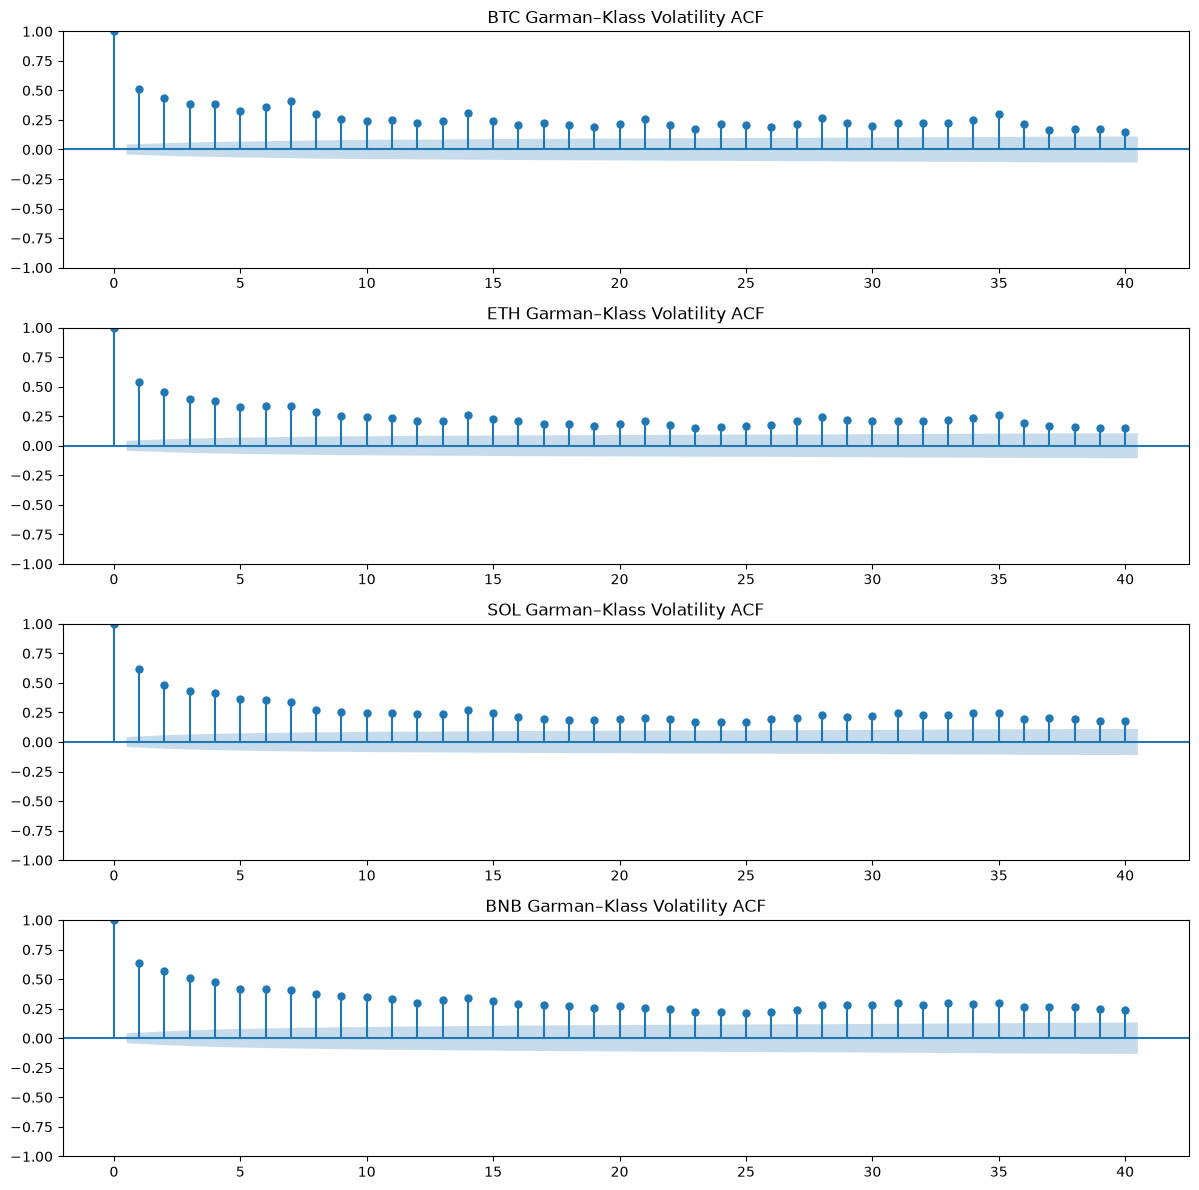

In [ ]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 12),
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    plot_acf(
        df["gk_volatility_annualized"].dropna(),
        lags=40,
        ax=ax,
    )

    ax.set_title(
        f"{asset} Garman–Klass Volatility ACF"
    )

plt.tight_layout()
plt.show()

The autocorrelation analysis reveals a clear distinction between return predictability and volatility predictability. Daily BTC log returns display relatively weak serial correlation, indicating limited linear predictability in return direction. In contrast, squared returns exhibit persistent positive autocorrelation across several lags, providing evidence of volatility clustering and conditional heteroskedasticity. The Garman–Klass volatility series display even stronger persistence across all four cryptocurrencies, with substantial positive autocorrelation extending over multiple weeks. These findings support the use of models specifically designed for persistent and time-varying volatility, including HAR-RV for multi-horizon realised-volatility dynamics and EGARCH for conditional heteroskedasticity in returns.

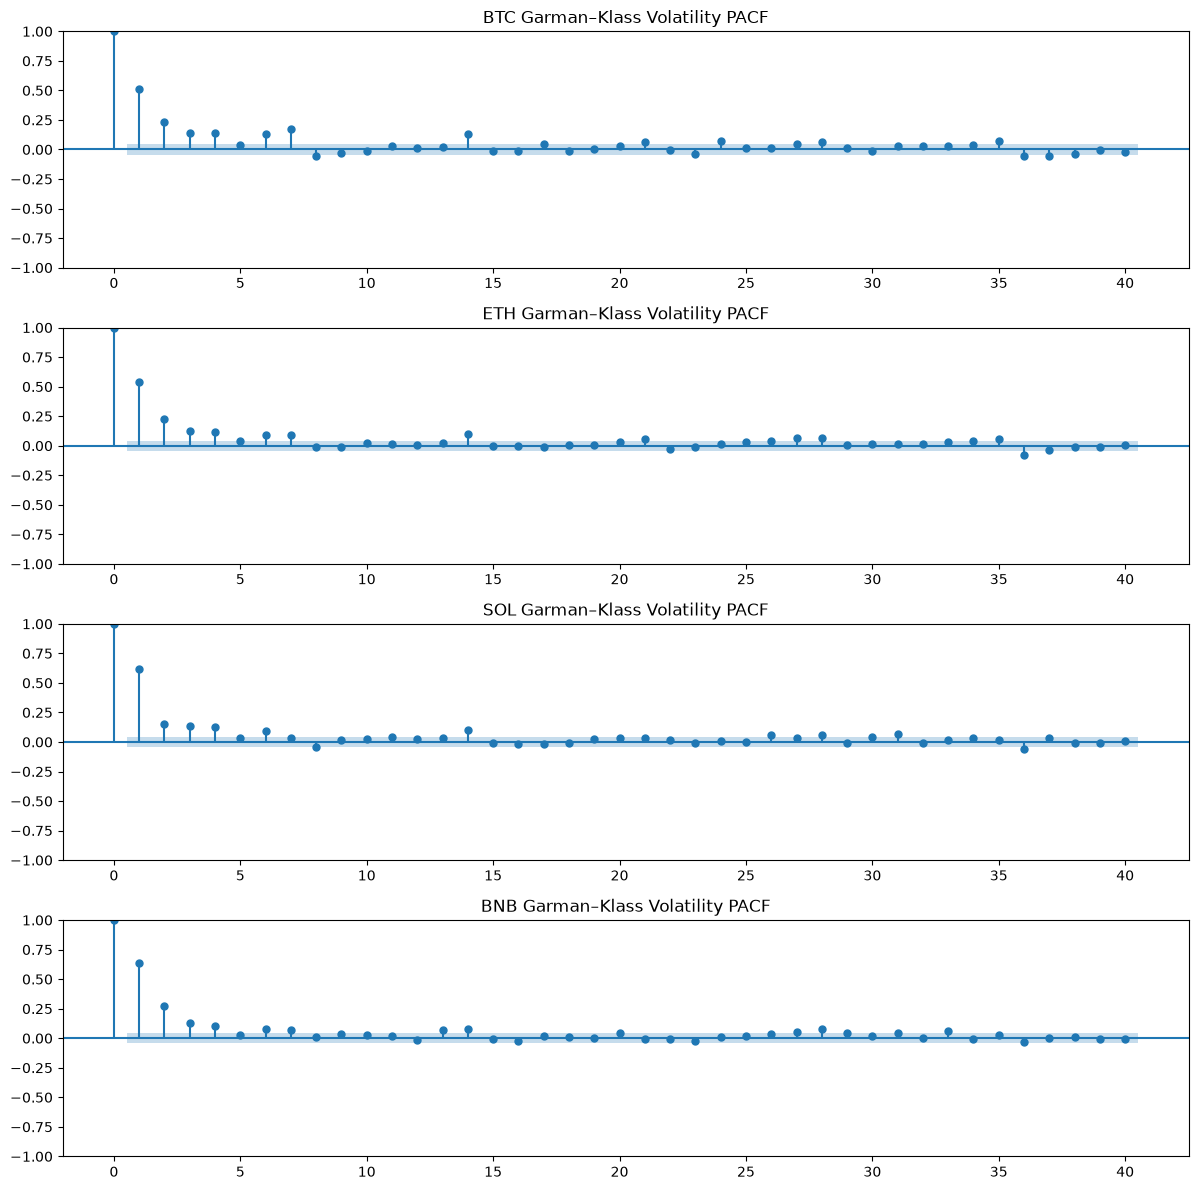

In [ ]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 12),
)

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    plot_pacf(
        df["gk_volatility_annualized"].dropna(),
        lags=40,
        ax=ax,
        method="ywm",
    )

    ax.set_title(
        f"{asset} Garman–Klass Volatility PACF"
    )

plt.tight_layout()
plt.show()

Raw returns exhibit relatively weak serial dependence, while squared returns and Garman–Klass volatility show substantially stronger autocorrelation.

This indicates that return direction is difficult to predict using simple linear dependence, but return magnitude and volatility are persistent.

The strong volatility ACF and shorter-lived PACF effects support parsimonious multi-horizon models such as HAR-RV, which capture daily, weekly, and monthly volatility components.

### ARCH-LM Test

In [45]:
arch_results = []

for asset, df in data.items():
    returns = df["log_return"].dropna()

    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
        returns,
        nlags=10,
    )

    arch_results.append(
        {
            "asset": asset,
            "lm_stat": lm_stat,
            "lm_pvalue": lm_pvalue,
            "f_stat": f_stat,
            "f_pvalue": f_pvalue,
        }
    )

arch_results = pd.DataFrame(arch_results)

arch_results

/home/whizic/UK/Machine-Learning/Crypto_Volatility_ML/.venv/lib/python3.14/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,asset,lm_stat,lm_pvalue,f_stat,f_pvalue
0,BTC,92.556735,1.664167e-15,9.632833,7.326600e-16
1,ETH,169.172609,4.115303e-31,18.307436,1.737832e-32
2,SOL,197.066050,6.600472e-37,21.639582,7.933843e-39
3,BNB,359.963138,3.057764e-71,43.240327,2.117463e-78


Engle's ARCH-LM test strongly rejects the null hypothesis of no ARCH effects across the four assets.

This indicates that conditional return variance changes through time and is related to previous shocks.

The result provides formal statistical justification for evaluating GARCH-family models, including EGARCH, during the modelling stage.

## 8. Stationarity Diagnostics

In [46]:
# augmented Dickey-Fuller test for stationarity
def run_adf_test(
    series: pd.Series,
    asset: str,
    variable: str,
    regression: str = "c",
) -> dict:
    series = series.dropna()

    result = adfuller(
        series,
        regression=regression,
        autolag="AIC",
    )

    return {
        "asset": asset,
        "variable": variable,
        "adf_statistic": result[0],
        "p_value": result[1],
        "lags_used": result[2],
        "n_observations": result[3],
    }

In [47]:
# KPSS helper function for stationarity testing
def run_kpss_test(
    series: pd.Series,
    asset: str,
    variable: str,
    regression: str = "c",
) -> dict:
    series = series.dropna()

    statistic, p_value, lags, _ = kpss(
        series,
        regression=regression,
        nlags="auto",
    )

    return {
        "asset": asset,
        "variable": variable,
        "kpss_statistic": statistic,
        "p_value": p_value,
        "lags_used": lags,
    }

### 8.1 Raw Price Stationarity

In [48]:
price_adf_results = []

for asset, df in data.items():
    result = run_adf_test(
        df["close"],
        asset=asset,
        variable="close_price",
        regression="ct",
    )

    price_adf_results.append(result)

price_adf_results = pd.DataFrame(price_adf_results)

price_adf_results

/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.1

,asset,variable,adf_statistic,p_value,lags_used,n_observations
0,BTC,close_price,-1.753140,0.726903,1,2103
1,ETH,close_price,-2.926829,0.153699,6,2098
2,SOL,close_price,-2.159850,0.512462,0,2104
3,BNB,close_price,-2.996359,0.133102,26,2078


In [49]:
price_kpss_results = []

for asset, df in data.items():
    result = run_kpss_test(
        df["close"],
        asset=asset,
        variable="close_price",
        regression="ct",
    )

    price_kpss_results.append(result)

price_kpss_results = pd.DataFrame(
    price_kpss_results
)

price_kpss_results

/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: Interp

,asset,variable,kpss_statistic,p_value,lags_used
0,BTC,close_price,0.861348,0.01,28
1,ETH,close_price,0.344062,0.01,28
2,SOL,close_price,0.470203,0.01,28
3,BNB,close_price,0.654830,0.01,28


### 8.2 Log Return Stationarity

In [50]:
return_adf_results = []

for asset, df in data.items():
    result = run_adf_test(
        df["log_return"],
        asset=asset,
        variable="log_return",
        regression="c",
    )

    return_adf_results.append(result)

return_adf_results = pd.DataFrame(return_adf_results)

return_adf_results

/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.1

,asset,variable,adf_statistic,p_value,lags_used,n_observations
0,BTC,log_return,-47.707892,0.000000e+00,0,2103
1,ETH,log_return,-47.702046,0.000000e+00,0,2103
2,SOL,log_return,-15.582818,1.923047e-28,7,2096
3,BNB,log_return,-11.698891,1.586173e-21,9,2094


In [51]:
return_kpss_results = []

for asset, df in data.items():
    result = run_kpss_test(
        df["log_return"],
        asset=asset,
        variable="log_return",
        regression="c",
    )

    return_kpss_results.append(result)

return_kpss_results = pd.DataFrame(
    return_kpss_results
)

return_kpss_results

/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  statistic, p_value, lags, _ = kpss(


,asset,variable,kpss_statistic,p_value,lags_used
0,BTC,log_return,0.093303,0.100000,6
1,ETH,log_return,0.145677,0.100000,2
2,SOL,log_return,0.488285,0.044305,7
3,BNB,log_return,0.370813,0.089736,3


### 8.3 Raw Garman-Klass Volatility Stationarity

In [52]:
# test Garman-Klass volatility estimator
volatility_adf_results = []

for asset, df in data.items():
    result = run_adf_test(
        df["gk_volatility_annualized"],
        asset=asset,
        variable="gk_volatility_annualized",
        regression="c",
    )

    volatility_adf_results.append(result)

volatility_adf_results = pd.DataFrame(volatility_adf_results)

volatility_adf_results

/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.1

,asset,variable,adf_statistic,p_value,lags_used,n_observations
0,BTC,gk_volatility_annualized,-5.225210,7.807803e-06,26,2078
1,ETH,gk_volatility_annualized,-5.392123,3.518654e-06,26,2078
2,SOL,gk_volatility_annualized,-6.867172,1.548459e-09,13,2091
3,BNB,gk_volatility_annualized,-6.036785,1.375988e-07,13,2091


In [53]:
volatility_kpss_results = []

for asset, df in data.items():
    result = run_kpss_test(
        df["gk_volatility_annualized"],
        asset=asset,
        variable="gk_volatility_annualized",
        regression="c",
    )

    volatility_kpss_results.append(result)

volatility_kpss_results = pd.DataFrame(
    volatility_kpss_results
)

volatility_kpss_results

/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: Interp

,asset,variable,kpss_statistic,p_value,lags_used
0,BTC,gk_volatility_annualized,3.327829,0.01,25
1,ETH,gk_volatility_annualized,2.174556,0.01,25
2,SOL,gk_volatility_annualized,3.912172,0.01,25
3,BNB,gk_volatility_annualized,2.938042,0.01,25


## 9. Log Garman-Klass Volatility

In [ ]:
for _asset, df in data.items():
    df["log_gk_volatility"] = np.log(
        df["gk_volatility"].clip(lower=1e-8)
    )

In [55]:
for asset, df in data.items():
    print(
        asset,
        "| GK min:", df["gk_volatility"].min(),
        "| GK max:", df["gk_volatility"].max(),
        "| Log GK min:", df["log_gk_volatility"].min(),
        "| Log GK max:", df["log_gk_volatility"].max(),
        "| Unique:", df["log_gk_volatility"].nunique(),
    )

BTC | GK min: 0.0023959088775919696 | GK max: 0.24587024071501623 | Log GK min: -6.033992630507238 | Log GK max: -1.402951358982811 | Unique: 2105
ETH | GK min: 0.0030087165819584114 | GK max: 0.37350460092365784 | Log GK min: -5.806241675880595 | Log GK max: -0.9848249560817682 | Unique: 2105
SOL | GK min: 0.006424681540448041 | GK max: 0.4662090816184298 | Log GK min: -5.047608215118294 | Log GK max: -0.7631210724792028 | Unique: 2105
BNB | GK min: 0.003911205148540258 | GK max: 0.346921690509646 | Log GK min: -5.543909730342488 | Log GK max: -1.058656200268594 | Unique: 2105


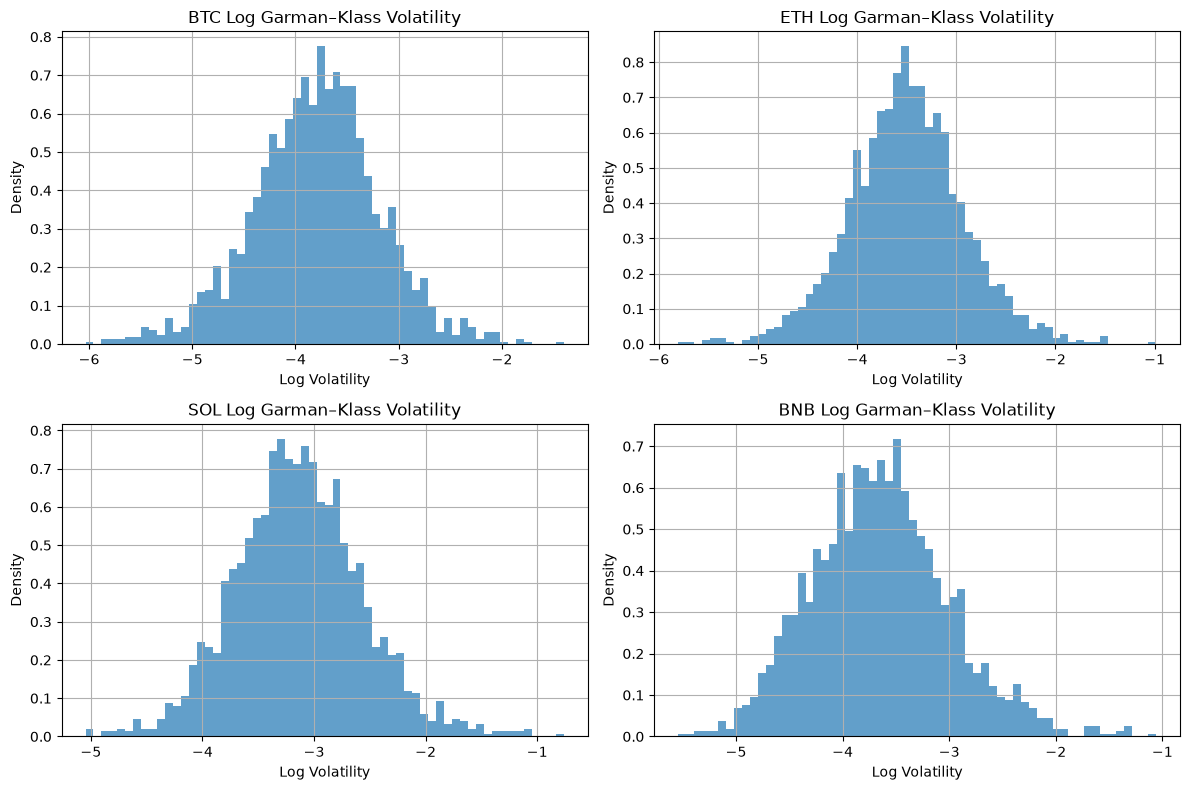

In [ ]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes = axes.flatten()

for ax, (asset, df) in zip(axes, data.items(), strict=True):
    volatility = (
        df["log_gk_volatility"]
        .dropna()
    )
    ax.hist(
        volatility,
        bins=60,
        density=True,
        alpha=0.7,
    )

    ax.set_title(
        f"{asset} Log Garman–Klass Volatility"
    )

    ax.set_xlabel("Log Volatility")
    ax.set_ylabel("Density")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [57]:
log_vol_adf_results = []

for asset, df in data.items():
    result = run_adf_test(
        df["log_gk_volatility"],
        asset=asset,
        variable="log_gk_volatility",
        regression="c",
    )

    log_vol_adf_results.append(result)

log_vol_adf_results = pd.DataFrame(
    log_vol_adf_results
)

log_vol_adf_results

/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_88019/1397392783.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.1

,asset,variable,adf_statistic,p_value,lags_used,n_observations
0,BTC,log_gk_volatility,-4.342712,0.000374,26,2078
1,ETH,log_gk_volatility,-4.232934,0.000579,26,2078
2,SOL,log_gk_volatility,-4.955850,0.000027,20,2084
3,BNB,log_gk_volatility,-4.167150,0.000749,26,2078


In [58]:
log_vol_kpss_results = []

for asset, df in data.items():
    result = run_kpss_test(
        df["log_gk_volatility"],
        asset=asset,
        variable="log_gk_volatility",
        regression="c",
    )

    log_vol_kpss_results.append(result)

log_vol_kpss_results = pd.DataFrame(
    log_vol_kpss_results
)

log_vol_kpss_results

/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, _ = kpss(
/tmp/ipykernel_88019/282669625.py:10: Interp

,asset,variable,kpss_statistic,p_value,lags_used
0,BTC,log_gk_volatility,3.489416,0.01,24
1,ETH,log_gk_volatility,2.073211,0.01,25
2,SOL,log_gk_volatility,4.346826,0.01,25
3,BNB,log_gk_volatility,3.209823,0.01,26


In [59]:
all_adf_results = pd.concat(
    [
        price_adf_results,
        return_adf_results,
        volatility_adf_results,
        log_vol_adf_results,
    ],
    ignore_index=True,
)

all_adf_results["reject_unit_root_5pct"] = (
    all_adf_results["p_value"] < 0.05
)

all_adf_results

,asset,variable,adf_statistic,p_value,lags_used,n_observations,reject_unit_root_5pct
0,BTC,close_price,-1.753140,7.269031e-01,1,2103,False
1,ETH,close_price,-2.926829,1.536993e-01,6,2098,False
2,SOL,close_price,-2.159850,5.124624e-01,0,2104,False
3,BNB,close_price,-2.996359,1.331017e-01,26,2078,False
4,BTC,log_return,-47.707892,0.000000e+00,0,2103,True
5,ETH,log_return,-47.702046,0.000000e+00,0,2103,True
6,SOL,log_return,-15.582818,1.923047e-28,7,2096,True
7,BNB,log_return,-11.698891,1.586173e-21,9,2094,True
8,BTC,gk_volatility_annualized,-5.225210,7.807803e-06,26,2078,True
9,ETH,gk_volatility_annualized,-5.392123,3.518654e-06,26,2078,True


In [60]:
all_kpss_results = pd.concat(
    [
        price_kpss_results,
        return_kpss_results,
        volatility_kpss_results,
        log_vol_kpss_results,
    ],
    ignore_index=True,
)

all_kpss_results["reject_stationarity_5pct"] = (
    all_kpss_results["p_value"] < 0.05
)

all_kpss_results

,asset,variable,kpss_statistic,p_value,lags_used,reject_stationarity_5pct
0,BTC,close_price,0.861348,0.010000,28,True
1,ETH,close_price,0.344062,0.010000,28,True
2,SOL,close_price,0.470203,0.010000,28,True
3,BNB,close_price,0.654830,0.010000,28,True
4,BTC,log_return,0.093303,0.100000,6,False
5,ETH,log_return,0.145677,0.100000,2,False
6,SOL,log_return,0.488285,0.044305,7,True
7,BNB,log_return,0.370813,0.089736,3,False
8,BTC,gk_volatility_annualized,3.327829,0.010000,25,True
9,ETH,gk_volatility_annualized,2.174556,0.010000,25,True


### Stationarity Interpretation

The ADF and KPSS tests provide complementary evidence about the time-series properties of prices, returns, and volatility.

Raw cryptocurrency price levels are clearly non-stationary. Trend-adjusted ADF tests fail to reject the unit-root null for BTC, ETH, SOL, and BNB, while trend-adjusted KPSS tests reject stationarity for all four assets. This supports modelling transformations such as returns rather than raw price levels.

Daily log returns display substantially stronger stationarity properties. ADF tests strongly reject the unit-root null for all four assets, while KPSS does not reject stationarity for BTC, ETH, and BNB. SOL provides a mildly conflicting result because KPSS rejects stationarity at the 5% level despite strong ADF evidence against a unit root. This may reflect structural changes, volatility regimes, or other forms of time-varying behaviour rather than a persistent stochastic trend.

Both raw Garman–Klass volatility and log Garman–Klass volatility strongly reject the unit-root null under ADF but also reject strict stationarity under KPSS. This indicates that cryptocurrency volatility is highly persistent and is likely affected by changing volatility regimes or structural shifts. The results are consistent with the earlier evidence of volatility clustering and long-lived high- and low-volatility periods.

The logarithmic transformation does not eliminate these regime-dependent dynamics, but it compresses extreme volatility observations and places the strictly positive volatility process on a more suitable modelling scale. For this reason, log Garman–Klass volatility remains a strong candidate for the forecasting target, although the final choice will be evaluated empirically during model validation rather than assumed in advance.

## 10. Volatility Regime Behaviour

To investigate whether volatility evolves through distinct risk environments, each asset's annualized Garman–Klass volatility is divided into low-, medium-, and high-volatility regimes using empirical terciles.

This is an exploratory regime definition rather than a forecasting rule. Any future live or backtesting threshold must be estimated using training data only to avoid look-ahead bias.

In [61]:
regime_data = {}

for asset, df in data.items():
    low_threshold = (
        df["gk_volatility_annualized"]
        .quantile(1 / 3)
    )

    high_threshold = (
        df["gk_volatility_annualized"]
        .quantile(2 / 3)
    )

    asset_regimes = df[
        [
            "timestamp",
            "gk_volatility_annualized",
        ]
    ].copy()

    asset_regimes["regime"] = pd.cut(
        asset_regimes["gk_volatility_annualized"],
        bins=[
            -np.inf,
            low_threshold,
            high_threshold,
            np.inf,
        ],
        labels=[
            "Low",
            "Medium",
            "High",
        ],
        include_lowest=True,
    )

    regime_data[asset] = asset_regimes

In [62]:
regime_thresholds = []

for asset, df in data.items():
    regime_thresholds.append(
        {
            "asset": asset,
            "low_upper_bound": (
                df["gk_volatility_annualized"]
                .quantile(1 / 3)
            ),
            "high_lower_bound": (
                df["gk_volatility_annualized"]
                .quantile(2 / 3)
            ),
        }
    )

regime_thresholds = pd.DataFrame(
    regime_thresholds
)

regime_thresholds

,asset,low_upper_bound,high_lower_bound
0,BTC,0.339851,0.551716
1,ETH,0.459630,0.721136
2,SOL,0.655666,1.039552
3,BNB,0.373546,0.631280


In [63]:
regime_counts = []

for asset, df in regime_data.items():
    counts = (
        df["regime"]
        .value_counts()
        .sort_index()
    )

    for regime, count in counts.items():
        regime_counts.append(
            {
                "asset": asset,
                "regime": regime,
                "count": count,
            }
        )

regime_counts = pd.DataFrame(
    regime_counts
)

regime_counts

,asset,regime,count
0,BTC,Low,702
1,BTC,Medium,701
2,BTC,High,702
3,ETH,Low,702
4,ETH,Medium,701
5,ETH,High,702
6,SOL,Low,702
7,SOL,Medium,701
8,SOL,High,702
9,BNB,Low,702


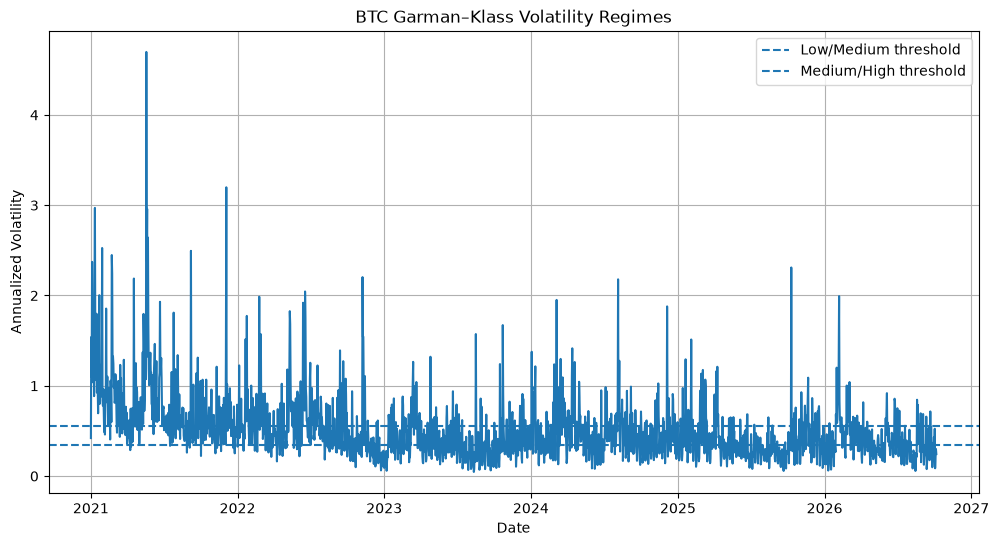

In [64]:
btc_regimes = regime_data["BTC"]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    btc_regimes["timestamp"],
    btc_regimes["gk_volatility_annualized"],
)

low_threshold = (
    data["BTC"]["gk_volatility_annualized"]
    .quantile(1 / 3)
)

high_threshold = (
    data["BTC"]["gk_volatility_annualized"]
    .quantile(2 / 3)
)

ax.axhline(
    low_threshold,
    linestyle="--",
    label="Low/Medium threshold",
)

ax.axhline(
    high_threshold,
    linestyle="--",
    label="Medium/High threshold",
)

ax.set_title(
    "BTC Garman–Klass Volatility Regimes"
)

ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend()
ax.grid(True)

plt.show()

In [65]:
regime_persistence = []

for asset, df in regime_data.items():
    current_regime = df["regime"]

    previous_regime = (
        current_regime.shift(1)
    )

    same_regime = (
        current_regime
        == previous_regime
    )

    persistence_rate = (
        same_regime.iloc[1:].mean()
    )

    regime_persistence.append(
        {
            "asset": asset,
            "same_regime_next_day_rate": (
                persistence_rate
            ),
        }
    )

regime_persistence = pd.DataFrame(
    regime_persistence
)

regime_persistence

,asset,same_regime_next_day_rate
0,BTC,0.483365
1,ETH,0.516160
2,SOL,0.538498
3,BNB,0.530894


In [66]:
btc_transition_matrix = pd.crosstab(
    btc_regimes["regime"].shift(1),
    btc_regimes["regime"],
    normalize="index",
)

btc_transition_matrix

regime,Low,Medium,High
regime,,,
Low,0.532097,0.338088,0.129815
Medium,0.328103,0.359486,0.312411
High,0.141026,0.300570,0.558405


In [67]:
for asset, df in regime_data.items():
    print(f"\n{asset}")

    transition_matrix = pd.crosstab(
        df["regime"].shift(1),
        df["regime"],
        normalize="index",
    )

    display(transition_matrix)


BTC


regime,Low,Medium,High
regime,,,
Low,0.532097,0.338088,0.129815
Medium,0.328103,0.359486,0.312411
High,0.141026,0.300570,0.558405



ETH


regime,Low,Medium,High
regime,,,
Low,0.570613,0.293866,0.135521
Medium,0.296719,0.407989,0.295292
High,0.133903,0.296296,0.569801



SOL


regime,Low,Medium,High
regime,,,
Low,0.592011,0.308131,0.099857
Medium,0.325250,0.399429,0.275321
High,0.084046,0.292023,0.623932



BNB


regime,Low,Medium,High
regime,,,
Low,0.604850,0.299572,0.095578
Medium,0.319544,0.382311,0.298146
High,0.076923,0.317664,0.605413


In [68]:
regime_summary = []

for asset, df in regime_data.items():
    low_threshold = (
        data[asset]["gk_volatility_annualized"]
        .quantile(1 / 3)
    )

    high_threshold = (
        data[asset]["gk_volatility_annualized"]
        .quantile(2 / 3)
    )

    current_regime = df["regime"]
    previous_regime = current_regime.shift(1)

    persistence_rate = (
        (current_regime == previous_regime)
        .iloc[1:]
        .mean()
    )

    regime_summary.append(
        {
            "asset": asset,
            "low_upper_bound": low_threshold,
            "high_lower_bound": high_threshold,
            "same_regime_next_day_rate": persistence_rate,
        }
    )

regime_summary = pd.DataFrame(
    regime_summary
)

regime_summary

,asset,low_upper_bound,high_lower_bound,same_regime_next_day_rate
0,BTC,0.339851,0.551716,0.483365
1,ETH,0.459630,0.721136,0.516160
2,SOL,0.655666,1.039552,0.538498
3,BNB,0.373546,0.631280,0.530894


### Volatility Regime Interpretation

Volatility regimes are defined using asset-specific terciles of annualized Garman–Klass volatility. These thresholds are used only for exploratory analysis and must not be used directly in backtesting or live trading because they are estimated from the full sample.

The transition matrices show meaningful persistence in both low- and high-volatility regimes. Low-volatility states remain low on the following day approximately 53%–60% of the time, while high-volatility states remain high approximately 56%–62% of the time.

SOL and BNB exhibit the strongest regime persistence, while BTC shows somewhat weaker persistence. Direct transitions between low and high volatility are relatively uncommon, with most regime changes occurring through the medium-volatility state.

These findings provide further evidence that cryptocurrency volatility evolves through persistent risk environments rather than behaving as an independent day-to-day process. This supports the later use of lagged volatility features, multi-horizon volatility models, and dynamic portfolio risk controls.

In [69]:
regime_summary

,asset,low_upper_bound,high_lower_bound,same_regime_next_day_rate
0,BTC,0.339851,0.551716,0.483365
1,ETH,0.459630,0.721136,0.516160
2,SOL,0.655666,1.039552,0.538498
3,BNB,0.373546,0.631280,0.530894


In [70]:
for asset, df in regime_data.items():
    print(f"\n{asset}")

    transition_matrix = pd.crosstab(
        df["regime"].shift(1),
        df["regime"],
        normalize="index",
    )

    display(transition_matrix)


BTC


regime,Low,Medium,High
regime,,,
Low,0.532097,0.338088,0.129815
Medium,0.328103,0.359486,0.312411
High,0.141026,0.300570,0.558405



ETH


regime,Low,Medium,High
regime,,,
Low,0.570613,0.293866,0.135521
Medium,0.296719,0.407989,0.295292
High,0.133903,0.296296,0.569801



SOL


regime,Low,Medium,High
regime,,,
Low,0.592011,0.308131,0.099857
Medium,0.325250,0.399429,0.275321
High,0.084046,0.292023,0.623932



BNB


regime,Low,Medium,High
regime,,,
Low,0.604850,0.299572,0.095578
Medium,0.319544,0.382311,0.298146
High,0.076923,0.317664,0.605413
